In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('./employee_attrition_dataset_10000.csv')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

In [9]:
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


In [10]:
df['Marital_Status'].unique()

array(['Single', 'Divorced', 'Married'], dtype=object)

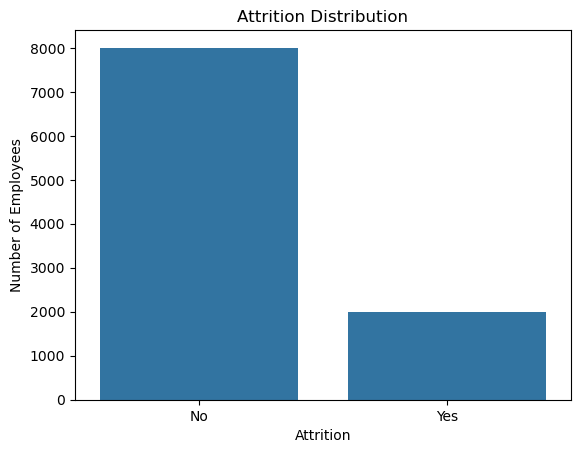

In [11]:
plt.figure()
sns.countplot(x="Attrition", data=df)

plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

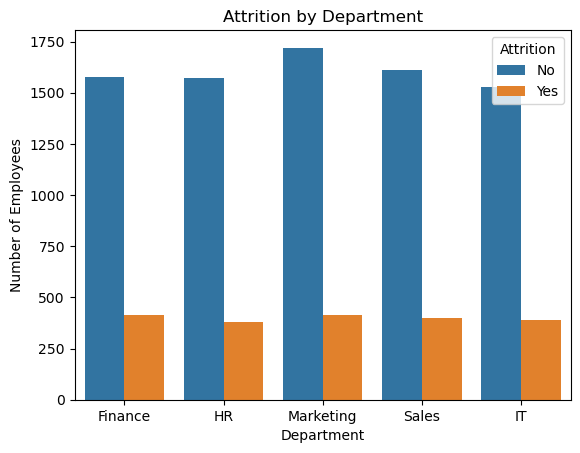

In [12]:
plt.figure()

sns.countplot(x="Department", hue="Attrition", data=df)

plt.title("Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.show()

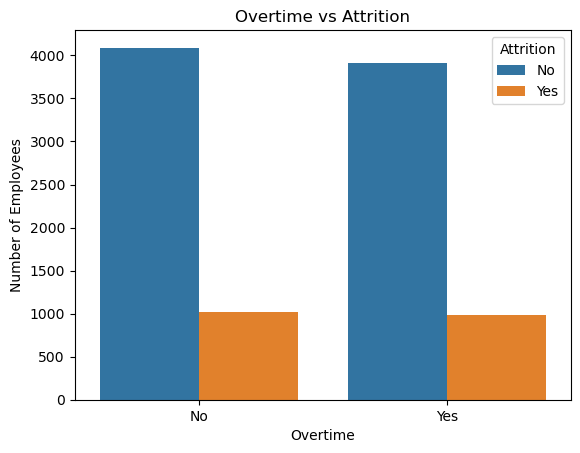

In [13]:
plt.figure()

sns.countplot(x="Overtime", hue="Attrition", data=df)

plt.title("Overtime vs Attrition")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")

plt.show()

<Figure size 640x480 with 0 Axes>

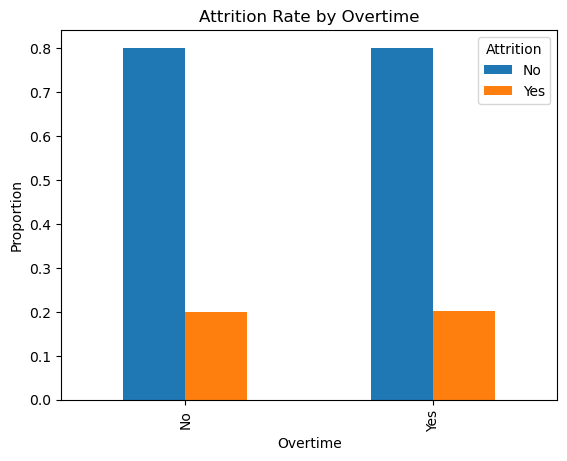

In [14]:
# คำนวณ attrition rate
overtime_attrition = pd.crosstab(df["Overtime"], df["Attrition"], normalize="index")

# plot
plt.figure()

overtime_attrition.plot(kind="bar")

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Proportion")

plt.show()

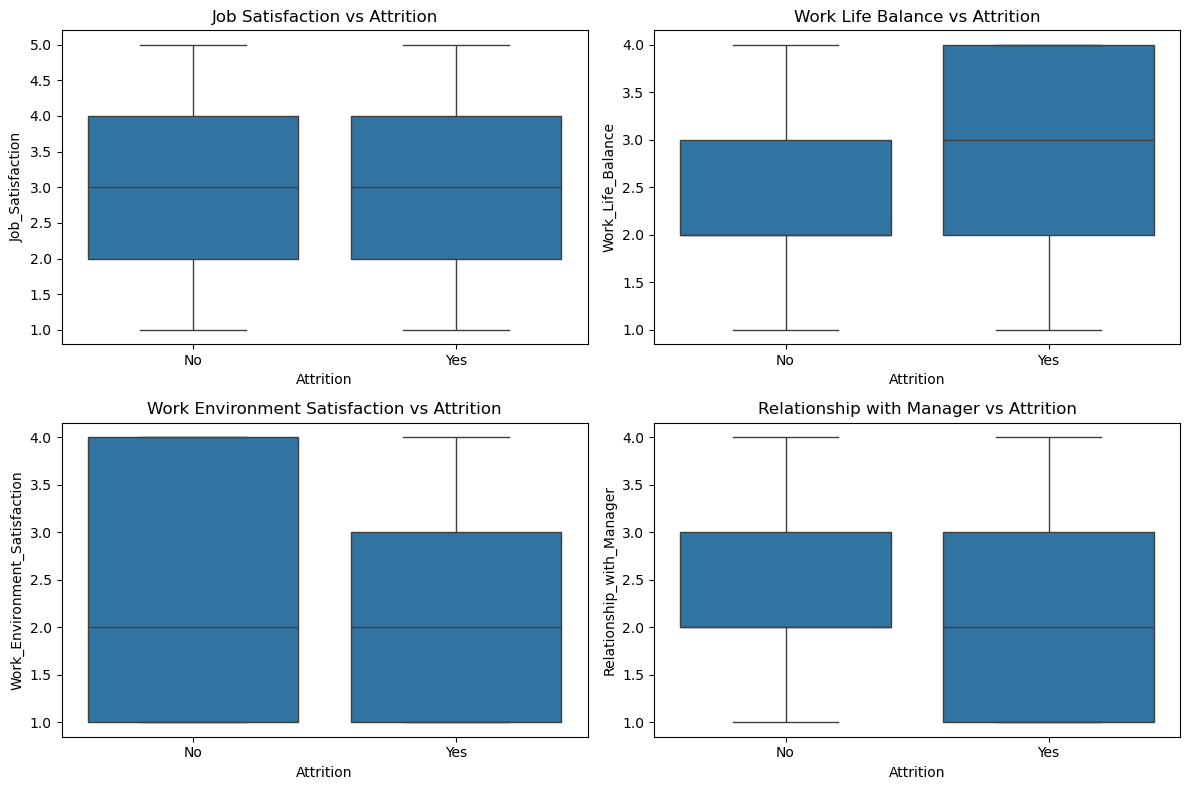

In [15]:

# สร้าง figure
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# 1 Job Satisfaction
sns.boxplot(x="Attrition", y="Job_Satisfaction", data=df, ax=axes[0,0])
axes[0,0].set_title("Job Satisfaction vs Attrition")

# 2 Work Life Balance
sns.boxplot(x="Attrition", y="Work_Life_Balance", data=df, ax=axes[0,1])
axes[0,1].set_title("Work Life Balance vs Attrition")

# 3 Work Environment Satisfaction
sns.boxplot(x="Attrition", y="Work_Environment_Satisfaction", data=df, ax=axes[1,0])
axes[1,0].set_title("Work Environment Satisfaction vs Attrition")

# 4 Relationship with Manager
sns.boxplot(x="Attrition", y="Relationship_with_Manager", data=df, ax=axes[1,1])
axes[1,1].set_title("Relationship with Manager vs Attrition")

plt.tight_layout()
plt.show()

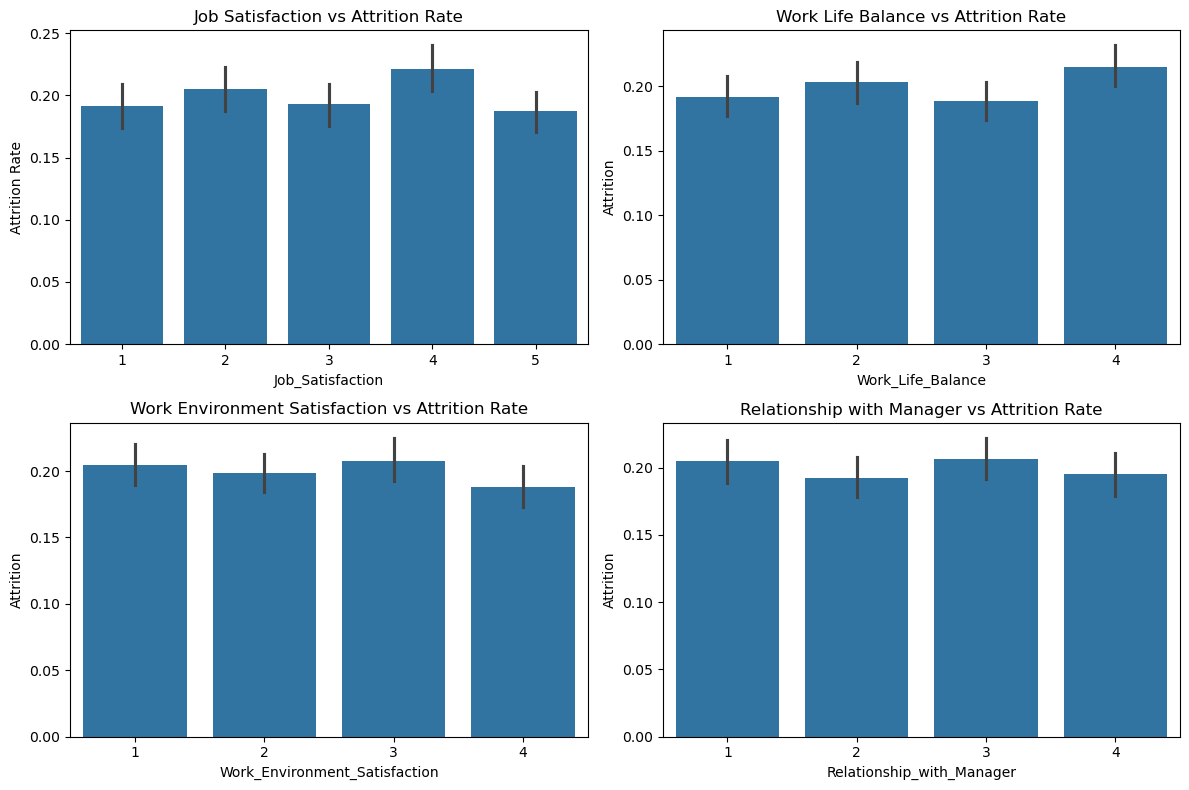

In [16]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

sns.barplot(x="Job_Satisfaction", y=(df["Attrition"]=="Yes"), data=df, ax=axes[0,0])
axes[0,0].set_title("Job Satisfaction vs Attrition Rate")
axes[0,0].set_ylabel("Attrition Rate")

sns.barplot(x="Work_Life_Balance", y=(df["Attrition"]=="Yes"), data=df, ax=axes[0,1])
axes[0,1].set_title("Work Life Balance vs Attrition Rate")

sns.barplot(x="Work_Environment_Satisfaction", y=(df["Attrition"]=="Yes"), data=df, ax=axes[1,0])
axes[1,0].set_title("Work Environment Satisfaction vs Attrition Rate")

sns.barplot(x="Relationship_with_Manager", y=(df["Attrition"]=="Yes"), data=df, ax=axes[1,1])
axes[1,1].set_title("Relationship with Manager vs Attrition Rate")

plt.tight_layout()
plt.show()

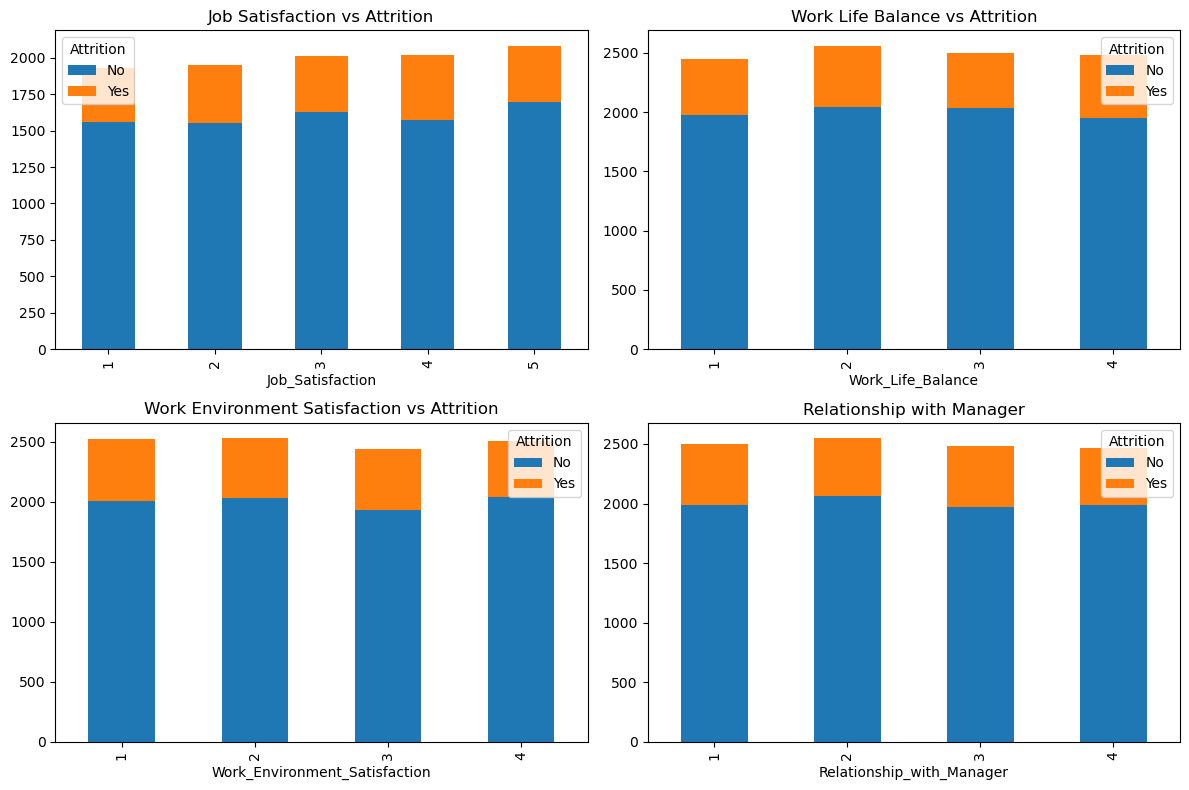

In [17]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

pd.crosstab(df["Job_Satisfaction"], df["Attrition"]).plot(kind="bar", stacked=True, ax=axes[0,0])
axes[0,0].set_title("Job Satisfaction vs Attrition")

pd.crosstab(df["Work_Life_Balance"], df["Attrition"]).plot(kind="bar", stacked=True, ax=axes[0,1])
axes[0,1].set_title("Work Life Balance vs Attrition")

pd.crosstab(df["Work_Environment_Satisfaction"], df["Attrition"]).plot(kind="bar", stacked=True, ax=axes[1,0])
axes[1,0].set_title("Work Environment Satisfaction vs Attrition")

pd.crosstab(df["Relationship_with_Manager"], df["Attrition"]).plot(kind="bar", stacked=True, ax=axes[1,1])
axes[1,1].set_title("Relationship with Manager")

plt.tight_layout()
plt.show()

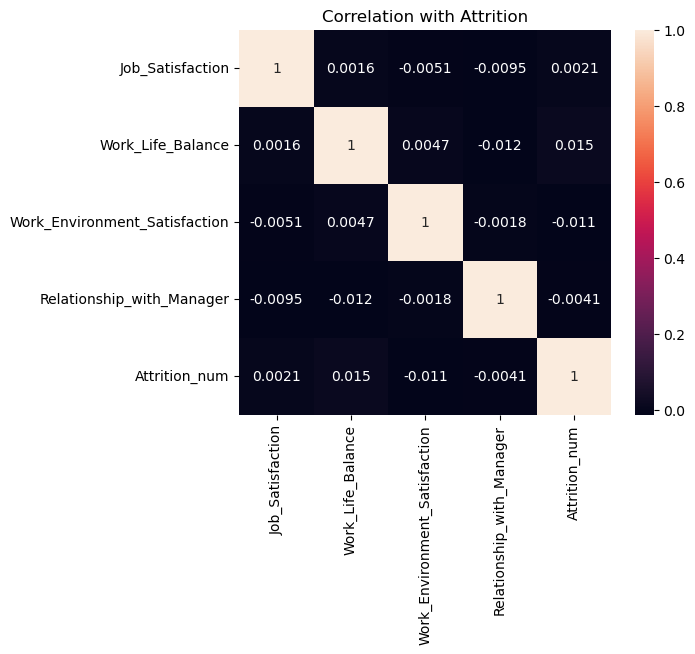

In [18]:
corr_features = [
    "Job_Satisfaction",
    "Work_Life_Balance",
    "Work_Environment_Satisfaction",
    "Relationship_with_Manager"
]

df["Attrition_num"] = df["Attrition"].map({"Yes":1,"No":0})

corr = df[corr_features + ["Attrition_num"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True)

plt.title("Correlation with Attrition")
plt.show()